# **Punto 1: Pronóstico de Demanda — *PredictIA* Core**

El Grupo Argos plantea un escenario operativo en el que las decisiones de abastecimiento dependen de la mejor señal disponible sobre el futuro. No se trata únicamente de “adivinar” la demanda: la organización necesita **anticipar con criterio** y **expresar la incertidumbre** con honestidad, porque de esa franja de duda dependen decisiones tácticas (cuánto comprar) y estratégicas (cómo planificar capacidades, inventarios y contratos).  

Este notebook aborda la primera pieza de ese rompecabezas: construir un **pronóstico mensual** robusto para los meses de **2022-05, 2022-06 y 2022-07**, sustentado en una exploración cuidadosa de los datos, una validación temporal transparente y modelos que prioricen estabilidad y explicabilidad. El resultado final no será solo un número; será una **estimación con contexto**: qué tan bien performa el modelo en el histórico, cuáles son sus supuestos y con qué nivel de confianza reporta el futuro.


## **1. Contexto y naturaleza del pronóstico de demanda**

*Pronosticar demanda*, en este contexto, es **traducir el pasado en una expectativa razonable del futuro**. La narrativa es simple: si la serie presenta patrones —tendencias suaves, estacionalidades, repeticiones— podemos capturarlos; si hay shocks, debemos reconocerlos y **reflejar esa volatilidad** en la amplitud de los intervalos. El objetivo no es vencer al azar en un punto, sino **ofrecer una señal confiable y accionable** para tres meses concretos del 2022.

La **utilidad de negocio** aparece en dos planos:

* **Operativo:** ajustar compras, planear inventarios y mitigar quiebres.  

* **Táctico-estratégico:** entender si el modelo “confía” en su propio pronóstico (intervalos) y cuándo conviene una revisión humana.


## **2. Enfoque metodológico y fundamentos del modelado temporal**

El proyecto prioriza **modelos de series de tiempo clásicos** por tres razones: entregan buen desempeño base, son interpretables y **producen intervalos de predicción nativos**. Se considerarán:

* **Naive / Seasonal Naive** como línea base honesta: si un modelo simple ya explica mucho, cualquier complejidad adicional debe justificarse.  

* **ETS (Error-Trend-Seasonal)**: capta nivel, tendencia y estacionalidad con componentes aditivos o multiplicativos.  

* **ARIMA/SARIMA / Auto-ARIMA**: incorpora correlación temporal y estacionalidad explícita, ofreciendo intervalos y diagnósticos residuales.

La **validación** será **temporal** (backtesting por bloques), no aleatoria: se evalúan ventanas de entrenamiento y se prueba hacia adelante, como ocurriría en producción. Para juzgar desempeño se reportarán:

* **sMAPE** (robusta ante escalas y cercana a MAPE sin caer en divisiones problemáticas),  

* **MAE** (error absoluto medio, fácil de interpretar),  

* **MASE** (normaliza contra un naive, útil para comparar entre modelos/series).

Con esto, el modelo elegido no será “el que mejor lució una vez”, sino **el que se comporta de manera estable** a través de ventanas de tiempo.


## **3. Análisis estructural preliminar de la serie temporal**

Una serie temporal bien entendida evita malos modelos. La exploración inicial busca responder tres preguntas sencillas:

1. **¿Cuál es la granularidad y cobertura real?** Asegurar que las fechas sean mensuales, sin huecos inadvertidos, y confirmar el rango que efectivamente alimentará el entrenamiento.  

2. **¿Qué patrones gobiernan la señal?** Observar **nivel, tendencia y estacionalidad**; realizar una descomposición clásica para ver si la estacionalidad es aditiva (amplitud estable) o multiplicativa (amplitud crece con el nivel).  

3. **¿Cómo se comportan los residuos del pasado?** Una mirada a **ACF/PACF** sugiere cuánto “recuerdo” contiene la serie; si el ruido está correlacionado, ARIMA gana sentido; si la estacionalidad domina, ETS/SARIMA suele responder mejor.

De esta lectura saldrán dos insumos: una **hipótesis de modelado** (qué probar primero) y un **plan de validación** (cómo partir el tiempo para ser justos con el futuro).


## **4. Evaluación exploratoria y caracterización visual de la demanda**

La visualización no busca decorar: pretende **mostrar, sin ambigüedad**, qué estructura hay. En esta fase se generarán:

* **Serie en nivel** (línea completa): ofrece la intuición global.  

* **Descomposición clásica** (nivel, tendencia, estacionalidad, residuo): revela el “motor” de la serie.  

* **ACF/PACF** sobre niveles (y sobre diferencias, si aplicara): indica memoria temporal y su alcance.  

* **Chequeo de huecos/outliers**: si los hay, se documenta si se imputan, se recortan o se mantienen (y por qué).

El resultado de la EDA no es una conclusión definitiva, sino un **mapa de ruta**: con qué modelos empezar y qué no esperar de ellos.


### **4.1 Ingesta e inspección inicial**

Prepara las importaciones esenciales para ingesta, limpieza y métricas, manteniendo dependencias limitadas y reproducibles. Estos imports se usan a lo largo del notebook; evitando los imports “perezosos” que generan confusión sobre el estado del entorno.

In [1]:
# importaciones estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing


Se establecen `PROJ_ROOT` y los directorios estándar (`DATA_DIR`, `FORECASTS_DIR`, `REPORTS_DIR`, `FIG_DIR`) para garantizar un almacenamiento consistente de los artefactos. Inicia el proceso con la carga del archivo para obtener una primera lectura del dataset: forma, cantidad de columnas, tipo, entre otros. 

Las rutas deben apuntar al repo actual. Si falla, la `assert` del dataset indicará la ruta absoluta para depuración.

In [2]:
# Configuración de rutas del proyecto
from pathlib import Path

# Opciones de visualización
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Función para hallar la raíz del proyecto
def find_project_root(start: Path | None = None) -> Path:
    """Sube directorios hasta hallar .git o README.md; si no, devuelve cwd."""
    p = Path.cwd() if start is None else Path(start)
    for parent in [p, *p.parents]:
        if (parent / ".git").exists() or (parent / "README.md").exists():
            return parent
    return Path.cwd()

# Raíz del proyecto
PROJ_ROOT = find_project_root()

# Directorios canónicos
DATA_DIR        = PROJ_ROOT / "data" / "raw"
FORECASTS_DIR   = PROJ_ROOT / "data" / "forecasts"
PREDICTIONS_DIR = PROJ_ROOT / "data" / "predictions"
MODELS_DIR      = PROJ_ROOT / "models_artifacts"
REPORTS_DIR     = PROJ_ROOT / "reports"
FIG_DIR         = REPORTS_DIR / "figures"

# Crear si no existen (solo los de salida)
for d in [FORECASTS_DIR, PREDICTIONS_DIR, MODELS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Archivos de entrada
F_DEMAND = DATA_DIR / "dataset_demand_acumulate.csv"

# Comprobación de existencia (muestra ruta absoluta si falla)
assert F_DEMAND.exists(), f"No se encontró el archivo: {F_DEMAND.resolve()}"

F_DEMAND  # para ver la ruta en la salida


WindowsPath('d:/OneDrive/GitHub/PredictIA/data/raw/dataset_demand_acumulate.csv')

**Reproducibilidad.** Se establecen semillas y se guarda `reports/run_metadata.json` que incluye versiones de librerías y el hash de git.

Asegura de que `reports/run_metadata.json` exista. No altera los resultados; simplemente documenta el entorno en el que se ejecuta.

In [3]:
# Reproducibilidad: semillas + huella de versiones 
import os, sys, json, random, platform, datetime as dt
from pathlib import Path

import numpy as np

# 1) Semillas determinísticas
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# 2) Versión de Python / SO
sys_info = {
    "timestamp": dt.datetime.now().isoformat(timespec="seconds"),
    "python": sys.version.split()[0],
    "platform": platform.platform(),
}

# 3) Versiones de librerías (optativo, robusto si alguna no está instalada)
def safe_version(modname, import_name=None):
    try:
        m = __import__(import_name or modname)
        v = getattr(m, "__version__", "unknown")
        return str(v)
    except Exception:
        return "not-installed"

lib_versions = {
    "numpy":        safe_version("numpy"),
    "pandas":       safe_version("pandas"),
    "matplotlib":   safe_version("matplotlib"),
    "scipy":        safe_version("scipy"),
    "statsmodels":  safe_version("statsmodels"),
    "sklearn":      safe_version("sklearn", "sklearn"),
    "pmdarima":     safe_version("pmdarima"),
    "prophet":      safe_version("prophet"),   # si no está, mostrará not-installed
}

# 4) Hash de git (si el repo existe)
git_info = {}
try:
    from subprocess import check_output, CalledProcessError
    git_dir = PROJ_ROOT / ".git"
    if git_dir.exists():
        git_info["rev"] = check_output(["git", "-C", str(PROJ_ROOT), "rev-parse", "--short", "HEAD"], text=True).strip()
        git_info["branch"] = check_output(["git", "-C", str(PROJ_ROOT), "rev-parse", "--abbrev-ref", "HEAD"], text=True).strip()
except Exception:
    git_info["rev"] = "unknown"
    git_info["branch"] = "unknown"

# 5) Consolidar y persistir huella en reports/run_metadata.json
RUN_META = {
    "seed": SEED,
    "system": sys_info,
    "libs": lib_versions,
    "git": git_info,
    "proj_root": str(PROJ_ROOT),
}

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
meta_path = REPORTS_DIR / "run_metadata.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(RUN_META, f, indent=2, ensure_ascii=False)

print("Semilla:", SEED)
print("Python:", sys_info["python"], "| numpy:", lib_versions["numpy"], "| pandas:", lib_versions["pandas"])
print("reports/run_metadata.json →", meta_path)


Semilla: 42
Python: 3.11.0 | numpy: 1.26.4 | pandas: 2.3.3
reports/run_metadata.json → d:\OneDrive\GitHub\PredictIA\reports\run_metadata.json


**Inspección estructural.** Verifica filas, columnas, tipos y fechas para asegurar la coherencia del conjunto de datos antes de realizar cualquier modelado.

Confirma: (i) cobertura temporal mensual, (ii) tipos correctos (`datetime` para fechas, `float` para demanda), (iii) ausencia de duplicados de fecha.

In [4]:
# Carga y primera inspección
df_dem = pd.read_csv(F_DEMAND)

print("Dimensiones:", df_dem.shape)        # (filas, columnas)
print("\nColumnas:", list(df_dem.columns)) # nombres tal cual vienen

print("\nTipos inferidos por pandas (dtypes):")
display(df_dem.dtypes)


Dimensiones: (64, 2)

Columnas: ['year_month', 'Demand']

Tipos inferidos por pandas (dtypes):


year_month     object
Demand        float64
dtype: object

In [5]:
print("\nPrimeras 5 filas:")
display(df_dem.head(5))



Primeras 5 filas:


,year_month,Demand
0,2017-01,1211.009490
1,2017-02,1660.584649
2,2017-03,3182.587014
3,2017-04,3506.515270
4,2017-05,4554.082280


In [6]:
print("\nÚltimas 5 filas:")
display(df_dem.tail(5))



Últimas 5 filas:


,year_month,Demand
59,2021-12,3006.311107
60,2022-01,217.314949
61,2022-02,332.062614
62,2022-03,609.119726
63,2022-04,1048.486287


In [7]:
print("\n.info():")
df_dem.info()


.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year_month  64 non-null     object 
 1   Demand      64 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.1+ KB


Los datos muestran que el conjunto tiene 64 registros y 2 variables. La primera columna, `year_month`, no se reconoce como fecha por pandas, sino como objeto. La otra columna, `Demand`, sí la identifica como de tipo `float64` (numérico de punto flotante).  

Vamos a estandarizar los nombres a `date` y `demand` para evitar errores más adelante y facilitar la lectura. El parseo de `date` se realiza de forma segura (`errors='coerce'`) para detectar formatos inconsistentes, si los hubiera.


In [8]:
# parseo de fecha mensual y renombrado de columnas
DATE_COL = "year_month"
DEMAND_COL = "Demand"

df_dem.rename(columns={DATE_COL: "date", DEMAND_COL: "demand"}, inplace=True)
df_dem["date"] = pd.to_datetime(df_dem["date"], format="%Y-%m", errors="coerce")
df_dem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    64 non-null     datetime64[ns]
 1   demand  64 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.1 KB


### **4.2 Validación del parseo de fechas:** 

Luego del proceso de conversión a `datetime`, es fundamental comprobar si todas las fechas fueron interpretadas correctamente.  

  Los valores que no logran convertirse al formato esperado (`%Y-%m`) son marcados por `pandas` como `NaT` (*Not a Time*), el equivalente temporal de `NaN`. Esto nos permite identificar posibles errores de digitación o filas con formato inconsistente antes de continuar con la exploración temporal.


In [9]:
# Contar cuántas fechas quedaron sin parsear
n_nat = df_dem["date"].isna().sum()

if n_nat == 0:
    print("Todas las fechas fueron interpretadas correctamente. No hay valores NaT.")
else:
    print(f"Se detectaron {n_nat} fechas no parseables. Se mostrarán a continuación:")
    display(df_dem[df_dem["date"].isna()])


Todas las fechas fueron interpretadas correctamente. No hay valores NaT.


### **4.3 Verificación de continuidad mensual y granularidad**

Antes de cualquier análisis estadístico, confirmamos que la serie:  

- está en **granularidad mensual** (primer día de cada mes),  
- no tiene **duplicados por mes**,  
- y no presenta **huecos** entre el primer y el último mes histórico.

Esta comprobación evita sesgos en la validación y en el cálculo de métricas de backtesting.


In [10]:
# Ordenamos por fecha (por claridad) y mostramos esquema mínimo
df_dem = df_dem.sort_values("date").reset_index(drop=True)
print("Esquema actual:")
display(df_dem.dtypes)

# Agregamos por mes de inicio (MS) para detectar duplicados y consolidar una fila por mes
ts_m = (
    df_dem.set_index("date")      # aseguramos índice temporal
          .resample("MS")["demand"]
          .sum()
          .reset_index()          # recupera 'date' como columna
)


print(f"Filas originales: {len(df_dem)}  |  Meses tras MS: {len(ts_m)}")
print(f"Rango temporal: {ts_m['date'].min().date()}  →  {ts_m['date'].max().date()}")

display(ts_m.head(6))
display(ts_m.tail(6))


Esquema actual:


date      datetime64[ns]
demand           float64
dtype: object

Filas originales: 64  |  Meses tras MS: 64
Rango temporal: 2017-01-01  →  2022-04-01


,date,demand
0,2017-01-01,1211.009490
1,2017-02-01,1660.584649
2,2017-03-01,3182.587014
3,2017-04-01,3506.515270
4,2017-05-01,4554.082280
5,2017-06-01,4839.985446


,date,demand
58,2021-11-01,2361.854906
59,2021-12-01,3006.311107
60,2022-01-01,217.314949
61,2022-02-01,332.062614
62,2022-03-01,609.119726
63,2022-04-01,1048.486287


**Completitud.** Verificar si hay meses faltantes o duplicados; los huecos distorsionan métricas y backtesting.

Si aparecen huecos, documentarlos y decidir: (i) imputar, (ii) excluir, o (iii) ajustar ventana de modelado.

In [11]:
# Detección de huecos en la serie mensual
full_range = pd.date_range(ts_m["date"].min(), ts_m["date"].max(), freq="MS")
missing = sorted(set(full_range) - set(ts_m["date"]))

print(f"Meses esperados en el rango: {len(full_range)}")
print(f"Meses presentes en datos:   {len(ts_m)}")
print(f"Huecos detectados:          {len(missing)}")

if missing:
    print("Meses faltantes (hasta 12 mostrados):", [d.strftime("%Y-%m") for d in missing[:12]])
else:
    print("La serie es mensual y continua en todo el rango.")


Meses esperados en el rango: 64
Meses presentes en datos:   64
Huecos detectados:          0
La serie es mensual y continua en todo el rango.


### **4.4 Caracterización de escala y valores atípicos**

Antes de descomponer o ajustar modelos, conviene conocer el orden de magnitud de la demanda y detectar puntos fuera de rango plausible. 

Nos enfocamos en:  

- **descriptivas básicas** (media, desviación, mínimos/máximos),  

- **percentiles** (p01–p99) para ver el “cuerpo” de la distribución,  

- una **señal visual** rápida en nivel para ubicar crestas/vales.

Esto ayuda a decidir si la serie requiere transformaciones (p. ej., log) o si la estacionalidad luce más aditiva que multiplicativa.


In [12]:
# Usamos ts_m (date, demand) ya validada
desc = ts_m["demand"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("demand")
display(desc)

p01, p99 = desc.loc["1%", "demand"], desc.loc["99%", "demand"]
mn, mx  = desc.loc["min", "demand"], desc.loc["max", "demand"]

print(f"Rango observado:   min={mn:.2f}  |  max={mx:.2f}")
print(f"Percentiles (1–99): p01={p01:.2f}  |  p99={p99:.2f}")

# Señalamos posibles atípicos fuera de [p01, p99] como primera referencia (no es decisión final)
mask_out = (ts_m["demand"] < p01) | (ts_m["demand"] > p99)
n_out = int(mask_out.sum())
print(f"Posibles atípicos por regla p01–p99: {n_out}")

if n_out:
    print("Ejemplos de posibles atípicos:")
    display(ts_m.loc[mask_out].head(5))


,demand
count,64.000000
mean,2600.044986
std,1943.995938
min,217.314949
1%,279.192135
5%,353.835702
25%,1034.370651
50%,1947.817229
75%,4216.465081
95%,6362.827720


Rango observado:   min=217.31  |  max=7686.31
Percentiles (1–99): p01=279.19  |  p99=7403.85
Posibles atípicos por regla p01–p99: 2
Ejemplos de posibles atípicos:


,date,demand
11,2017-12-01,7686.307292
60,2022-01-01,217.314949


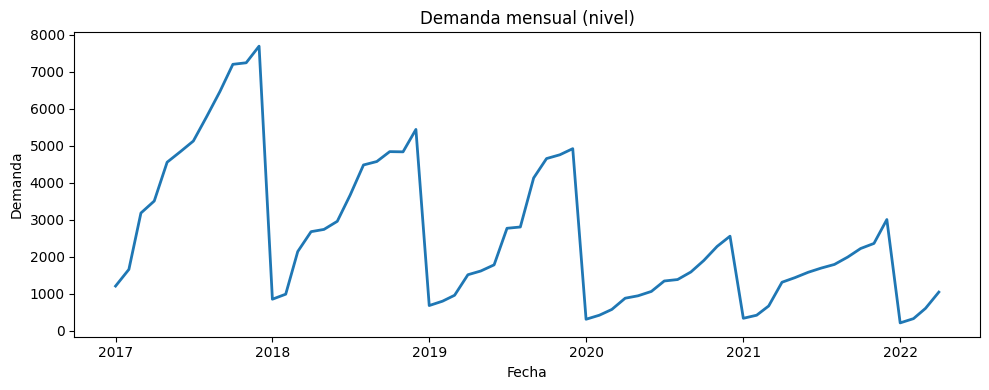

In [13]:
fig = plt.figure(figsize=(10, 4))
plt.plot(ts_m["date"], ts_m["demand"], linewidth=2)
plt.title("Demanda mensual (nivel)")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.tight_layout()
plt.show()


La serie mensual de demanda (2017–2022) muestra un **patrón cíclico anual**: comienza con niveles bajos, llega a un pico a fin de año y luego cae abruptamente al siguiente. Aunque esto podría aparentar una estacionalidad constante que modelos como **[ETS](https://otexts.com/fpp3/ses.html) o [ARIMA](https://otexts.com/fpp3/arima.html)** podrían captar, un análisis más profundo revela una **reducción progresiva en la altura de los picos**, indicando una **fatiga estructural en la demanda**.  

Este debilitamiento significa que la **amplitud de los ciclos varía en proporción al nivel**, por lo que un [enfoque **multiplicativo** o una **transformación logarítmica**](https://otexts.com/fpp3/) es más apropiado que un modelo aditivo. Además, la media global deja de ser una medida representativa, siendo preferibles medidas robustas como la **mediana** y los **cuantiles**.  

Los valores extremos observados entre diciembre de 2017 ($\sim 7686$) y enero de 2022 ($\sim 217$), establecen los límites del rango observado, sin indicar rupturas ni datos faltantes. Para evaluar objetivamente la tendencia a la baja, se sugiere resumir la serie por año calculando la **mediana**, el **máximo** y la **razón (máximo/mediana)**, con el objetivo de comprobar la reducción en la amplitud.  

### **4.5 Resumen anual: mediana, máximo y razón máximo/mediana**

Con el fin de analizar la reducción del ciclo, la serie se agrupó por año y se calcularon:
- **Mediana anual**: centro robusto de la demanda.  

- **Máximo anual**: fuerza máxima del pico estacional.  

- **Razón (max/mediana)**: amplitud relativa del ciclo.  

Una caída sistemática en el máximo y/o en la razón confirmaría la pérdida de intensidad estacional a lo largo del tiempo.


In [14]:
# Partimos de ts_m con columnas: date (datetime mensual MS), demand (float)
annual = (
    ts_m.assign(year=ts_m["date"].dt.year)
        .groupby("year", as_index=False)
        .agg(
            mediana=("demand", "median"),
            maximo=("demand", "max"),
            n_meses=("demand", "size"),
        )
)
annual["razon_max_mediana"] = annual["maximo"] / annual["mediana"]

print("Resumen anual (mediana, máximo, razón):")
display(annual)


Resumen anual (mediana, máximo, razón):


,year,mediana,maximo,n_meses,razon_max_mediana
0,2017,4982.937029,7686.307292,12,1.542525
1,2018,3313.540931,5438.445968,12,1.641279
2,2019,2277.264771,4919.823330,12,2.160409
3,2020,1207.295887,2557.306905,12,2.118211
4,2021,1639.618291,3006.311107,12,1.833543
5,2022,470.591170,1048.486287,4,2.228019


### **4.6 Evolución de picos y centro anual**

El gráfico contrasta, por año, la **mediana** (tendencia central) y el **máximo** (intensidad del pico). Si ambos disminuyen y la **razón máxima/mediana** también disminuye, esto refuerza la hipótesis de una estacionalidad proporcional con amplitud decreciente.


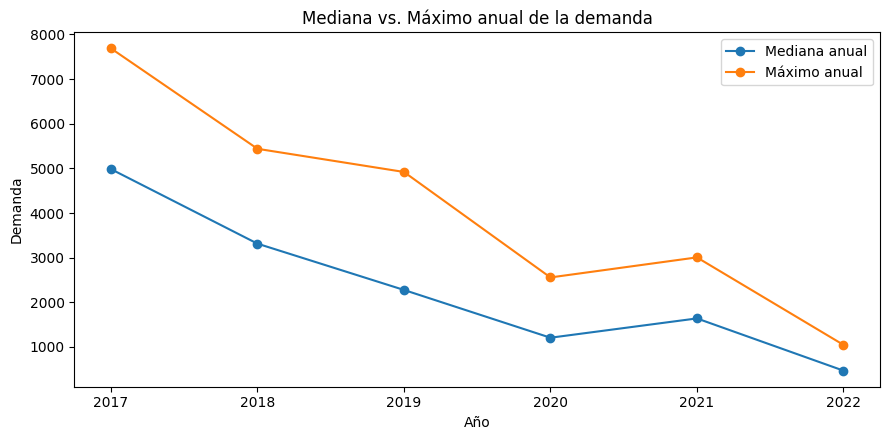

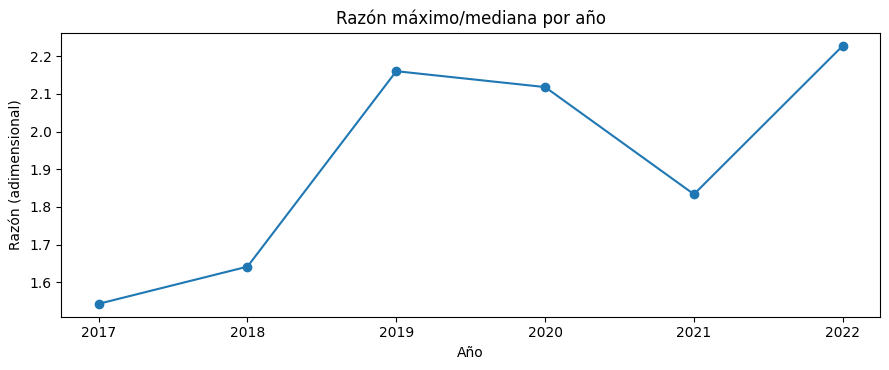

In [15]:
fig = plt.figure(figsize=(9, 4.5))
plt.plot(annual["year"], annual["mediana"], marker="o", label="Mediana anual")
plt.plot(annual["year"], annual["maximo"], marker="o", label="Máximo anual")
plt.title("Mediana vs. Máximo anual de la demanda")
plt.xlabel("Año")
plt.ylabel("Demanda")
plt.legend()
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(9, 3.8))
plt.plot(annual["year"], annual["razon_max_mediana"], marker="o")
plt.title("Razón máximo/mediana por año")
plt.xlabel("Año")
plt.ylabel("Razón (adimensional)")
plt.tight_layout()
plt.show()


La comparación entre la **mediana** y el **máximo anual** confirma una **tendencia descendente sostenida** en ambos indicadores. Entre 2017 y 2022, la mediana anual disminuye de aproximadamente $5000$ a menos de $1000$ unidades, mientras que los picos bajan de casi $8000$ a un poco más de $1000$. Esta reducción simultánea en el nivel central y en los máximos indica una **tendencia estructural a la baja**, acompañada de una **estacionalidad amortiguada**: los ciclos se repiten, pero cada año con menor magnitud.  

La razón **máximo/mediana** no presenta una caída continua, sino que muestra fluctuaciones moderadas. Esto sugiere que, aunque el volumen total disminuye, la **proporción entre los picos y el nivel medio** permanece relativamente estable. En otras palabras, la demanda baja en escala, pero mantiene su patrón cíclico.  

Estas observaciones conducen a tres conclusiones prácticas para el modelado:  

* Se recomienda la **transformación logarítmica** para estabilizar la varianza y evitar que los valores elevados dominen el ajuste.  

* La serie debe utilizar un esquema **multiplicativo** que represente la relación proporcional entre la estacionalidad y el nivel.  

* Se sugiere usar un modelo con **tendencia amortiguada** que pueda captar cómo disminuyen gradualmente los picos.  

El siguiente paso en el análisis exploratorio de datos (EDA) es realizar una **[descomposición estacional STL](https://otexts.com/fpp3/stl.html)** tanto en nivel como en logaritmo. Esto permite confirmar de manera cuantitativa esta estructura y preparar la serie para el modelado de pronósticos.


### **4.7 Descomposición estacional (STL): nivel vs. log**

**[STL (Seasonal–Trend decomposition using LOESS)](https://otexts.com/fpp3/stl.html)** es un método no paramétrico que descompone una serie $y_t$ en tres componentes:

$$y_t = T_t + S_t + R_t \quad (\text{aditiva})$$

donde $T_t$ es la **tendencia** (movimiento de largo plazo), $S_t$ la **estacionalidad** (patrón periódico, p.ej. 12 meses) y $R_t$ el **residuo** (lo no explicado).

La estimación se hace con **[LOESS](https://www.scb.se/contentassets/ca21efb41fee47d293bbee5bf7be7fb3/stl-a-seasonal-trend-decomposition-procedure-based-on-loess.pdf)** (suavizado local), lo que permite:

* **Estacionalidad que varía lentamente en el tiempo** (no exige que sea rígida).  

* **Robustez a atípicos** (`robust=True` los atenúa, en vez de arrastrar la tendencia).  

* Control explícito del **periodo** (12 meses en este ejercicio).

STL es **aditivo por construcción**. Si la estacionalidad parece **proporcional al nivel** (amplitud mayor cuando el nivel es alto), se recomienda transformar la serie (p.ej. **log1p**) y descomponer en ese espacio: la aditividad sobre el log equivale, aproximadamente, a un **modelo multiplicativo en nivel**.

En resumen, STL ofrece una radiografía “limpia” de:

* si hay **tendencia decreciente** real (no confundida por picos),  

* cómo se comporta la **estacionalidad** (forma y amplitud),  

* y cuánto **ruido** queda (y si ese ruido cambia con el nivel).

<Figure size 1000x600 with 0 Axes>

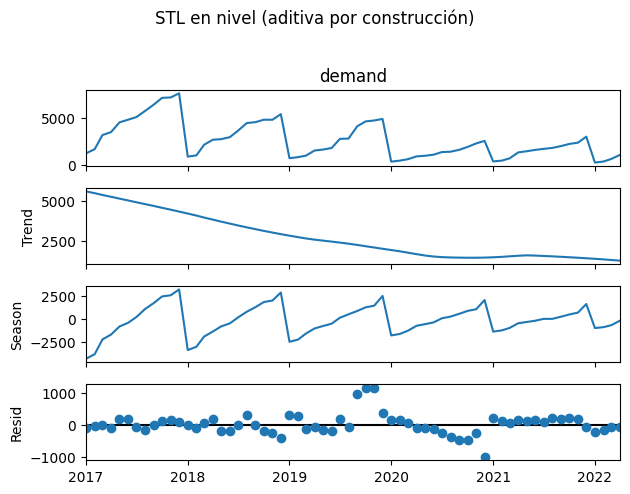

In [16]:
y = ts_m.set_index("date")["demand"].asfreq("MS")

stl_lin = STL(y, period=12, robust=True).fit()

fig = plt.figure(figsize=(10, 6))
stl_lin.plot()
plt.suptitle("STL en nivel (aditiva por construcción)", y=1.02)
plt.tight_layout()
plt.show()


Con base en estos resultados, se presenta a continuación un breve análisis.

1. **Tendencia (Trend):** Desciende de forma sostenida desde $\sim$ 2017 hasta $\sim$ 2021, con una leve meseta/tímido repunte a inicios de 2021 y nueva caída hacia 2022. Esto confirma una **tendencia estructural a la baja**.

2. **Estacionalidad (Season):** Patrón anual muy marcado: crecimiento progresivo dentro del año, pico al cierre y **quiebre brusco** al inicio del siguiente. La amplitud aparente es grande cuando el nivel es alto (2017–2019) y menor cuando el nivel cae (2021–2022). Esa relación “amplitud $\propto$ nivel” es señal de **comportamiento multiplicativo**.

3. **Residuo (Resid):** Variabilidad mayor alrededor de 2019 (cuando el nivel es alto) y menor en 2021–2022 (nivel bajo). Es decir, **[heterocedasticidad](https://www.sciencedirect.com/topics/engineering/heteroscedasticity)**: el ruido crece con el nivel, otro indicio de que conviene trabajar en **log** para estabilizar la varianza. No se observan patrones residuales fuertes de periodicidad no capturada; el remanente luce razonablemente centrado.

De lo expuesto, se desprende que la decisión práctica más adecuada es:

* Transformar la serie: **$z_t=\log(1+y_t)$** para estabilizar varianza y trabajar con **estacionalidad aditiva en log** ($\approx$ multiplicativa en nivel).  

* Modelos candidatos acordes con la lectura:

  * **[ETS(M, Ad, M)](https://otexts.com/fpp3/ses.html)** con **tendencia amortiguada** (o ETS en log con componentes aditivos)  
  * **[SARIMA](https://otexts.com/fpp3/seasonal-arima.html)** sobre $z_t$ (log), con estacionalidad ($s=12$), evaluando términos AR/MA parcimoniosos.
* Mantener la validación temporal ya acordada ($train \le$ 2021-12; $valid = $ 2022-01 $\ldots$ 04).

Los pasos a seguir en el EDA serán:

1. Repetir STL en **log** (ya contamos con el script base). Y esperamos encontrar **estacionalidad de amplitud casi constante** y **residuo más homocedástico**.  

2. Con esto realizado, **cerramos EDA**: dejamos fijados transformación, tipo de estacionalidad y esquema de validación.



### **4.8 Cierre de la EDA y transición al modelado**

La EDA mostró una serie mensual constante, con una estacionalidad anual evidente, una tendencia a la baja y una amplitud que aumenta en función del nivel.  

Para estabilizar la varianza y representar una estacionalidad proporcional, se trabajará sobre `z_t = log(1 + demand)` y se evaluará en nivel aplicando `expm1` al pronóstico.  

Antes de ajustar los modelos, se fijan cortes temporales y se calculan líneas base honestas.  

El objetivo es dimensionar la dificultad del problema y establecer un umbral mínimo de calidad que los modelos (ETS/SARIMA) deben superar.



In [17]:
import numpy as np
import pandas as pd

# Serie mensual ya consolidada en ts_m con columnas ['date','demand']
y = ts_m.set_index("date")["demand"].asfreq("MS").astype(float)

# Corte sugerido: entrenar todo hasta 2021-12 y validar en 2022-01..04
train_end   = "2021-12-01"
valid_start = "2022-01-01"
valid_end   = "2022-04-01"

y_train = y.loc[:train_end]
y_valid = y.loc[valid_start:valid_end]

# Transformación para modelar; la evaluación se hará en nivel (destransformando)
z_train = np.log1p(y_train)
z_last  = z_train.iloc[-1]
z_valid_index = y_valid.index  # fechas objetivo de la validación


**Líneas base en log: Naive y Seasonal-Naive**

 En un proceso de pronóstico, antes de usar algoritmos complejos como ETS, ARIMA o modelos de aprendizaje automático, se define una **línea base de desempeño**, también conocida como **baseline**.  

Un baseline no busca ser “inteligente”; su propósito es actuar como un **punto de comparación objetivo**. Ayuda a responder una pregunta clave:  

> ¿el modelo propuesto realmente aporta valor frente a una predicción ingenua?  

En el caso de esta serie de demanda, se utilizaron dos baselines:  

1. **Naive(log):** mantiene el último valor registrado del entrenamiento (lo que implica que la demanda del mes siguiente será igual a la de diciembre de 2021). Es el método más básico de referencia.  

2. **Seasonal-Naive(log):** repite el valor de hace **12 meses** (por ejemplo, enero de 2021 para pronosticar enero de 2022). Esta referencia es más rigurosa, ya que incluye el patrón estacional que ya conocemos.  

Ambas se calcularon en el espacio logarítmico, donde el modelo operará, y luego se transformaron de vuelta al nivel original para evaluar el error mediante métricas interpretables.



In [18]:
# Métricas de evaluación
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    out = np.zeros_like(denom, dtype=float)
    out[mask] = 2.0 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]
    return out.mean()

# Métrica MAE
def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

# Métrica MASE estacional
def mase_seasonal(y_true, y_pred, y_train, s=12):
    y_true  = np.asarray(y_true, dtype=float)
    y_pred  = np.asarray(y_pred, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    diffs = np.abs(y_train[s:] - y_train[:-s])
    scale = diffs.mean() if len(diffs) else np.nan
    if not scale or np.isnan(scale):
        return np.nan
    return mae(y_true, y_pred) / scale

# Baseline 1: Naive en log (repite el último z_train)
z_pred_naive = pd.Series(z_last, index=z_valid_index)
y_pred_naive = np.expm1(z_pred_naive)  # volver a nivel

# Baseline 2: Seasonal-Naive en log (valor de hace 12 meses)
lag_12_idx = z_valid_index - pd.DateOffset(years=1)
z_pred_snaive = z_train.reindex(lag_12_idx).to_numpy()
# Si alguna fecha no existiera por cobertura, se usa el último z_train
z_pred_snaive = np.where(np.isnan(z_pred_snaive), z_last, z_pred_snaive)
y_pred_snaive = np.expm1(z_pred_snaive)

# Métricas en nivel
y_true = y_valid.to_numpy()
res_baselines = pd.DataFrame({
    "modelo": ["Naive(log)", "Seasonal-Naive(log)"],
    "sMAPE":  [smape(y_true, y_pred_naive.values),
               smape(y_true, y_pred_snaive)],
    "MAE":    [mae(y_true, y_pred_naive.values),
               mae(y_true, y_pred_snaive)],
    "MASE":   [mase_seasonal(y_true, y_pred_naive.values, y_train.values, s=12),
               mase_seasonal(y_true, y_pred_snaive,      y_train.values, s=12)],
})
display(res_baselines)

# Tabla de validación (opcional, para lectura ejecutiva)
val_table = pd.DataFrame({
    "date":    z_valid_index,
    "y_true":  y_valid.values,
    "naive":   y_pred_naive.values,
    "snaive":  y_pred_snaive
})
display(val_table)


,modelo,sMAPE,MAE,MASE
0,Naive(log),1.406061,2454.565213,2.521223
1,Seasonal-Naive(log),0.253388,136.668113,0.140380


,date,y_true,naive,snaive
0,2022-01-01,217.314949,3006.311107,341.432367
1,2022-02-01,332.062614,3006.311107,424.121268
2,2022-03-01,609.119726,3006.311107,673.748842
3,2022-04-01,1048.486287,3006.311107,1314.353551


Los resultados indican que el método **Seasonal-Naive** presenta errores mucho menores (sMAPE $\approx 0,25$; MASE $\approx 0,14$) en comparación con el **Naive** (sMAPE $\approx 1,41$; MASE $\approx 2,52$). Esto demuestra que la serie está dominada por una **estructura estacional anual estable**, por lo que cualquier modelo estadístico que se ajuste deberá **superar este rendimiento** para considerarse una mejora significativa.  

Con esta verificación, se concluye la fase de establecimiento de referencias y el análisis puede continuar hacia el **modelado formal**, que comienza con un esquema **ETS en log** y un **SARIMA estacional**, ambos evaluados usando las mismas métricas y horizonte.


## **5 Modelo estadístico: pronóstico con ETS y SARIMA**

Tras finalizar la exploración, la serie muestra una tendencia a la baja y un patrón estacional anual constante en forma, aunque reducido en magnitud. El modelado se hará usando la transformación `log1p(demand)`, que estabiliza la varianza y facilita un tratamiento aditivo de la estacionalidad, lo cual es equivalente a una estructura multiplicativa en nivel.  

El propósito no es sobreajustar, sino **comparar dos enfoques complementarios**: un modelo de suavización exponencial (ETS) y un modelo autorregresivo estacional (sARIMA). Ambos se entrenan con datos hasta diciembre de 2021 y se prueban con datos de enero a abril de 2022, evaluando su capacidad para predecir la tendencia bajista y reproducir la dinámica anual.  

Las métricas utilizadas serán las mismas que en las líneas base: [**sMAPE**, **MAE** y **MASE**.](https://otexts.com/fpp3/accuracy.html)


### **5.1 Modelo ETS**

El modelo **[ETS](https://otexts.com/fpp3/ses.html)** combina tres componentes:  

- una tendencia suavizada y **amortiguada**, que atenúa las proyecciones lineales para evitar sobreestimaciones,  

- una estacionalidad **aditiva en log** (equivalente a multiplicativa en nivel), que preserva la forma cíclica detectada,  

- y una componente de error exponencialmente ponderada.

Este esquema es especialmente adecuado para series con estructura regular y fatiga progresiva, como la observada aquí.  

Su simplicidad y capacidad de adaptación lo hacen un punto de referencia sólido antes de introducir términos autorregresivos.



In [19]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Serie transformada
z_train = np.log1p(y_train)
z_valid = np.log1p(y_valid)

# Modelo ETS: tendencia amortiguada (add) + estacionalidad aditiva
ets_model = ExponentialSmoothing(
    z_train,
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=12,
).fit(optimized=True, use_brute=True)

# Pronóstico sobre el horizonte de validación
z_forecast_ets = ets_model.forecast(len(z_valid))
y_forecast_ets = np.expm1(z_forecast_ets)  # volver a nivel


### **5.2 Modelo sARIMA**

El modelo **[sARIMA](https://otexts.com/fpp3/seasonal-arima.html)** permite capturar dependencias autorregresivas y patrones de correlación temporal más complejos que el ETS.  

La estructura $(1,1,1)(1,1,1,12)$ implica:

- una diferencia ordinaria y una diferencia estacional (para eliminar tendencia y estacionalidad persistentes),  

- un término autorregresivo y uno de medias móviles tanto en la parte regular como en la estacional,  

- una periodicidad de 12 meses.

En conjunto, el modelo busca aprovechar la correlación temporal reciente y el patrón anual para mejorar la previsión sobre la fase descendente detectada en los últimos periodos.


In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA(p,d,q)(P,D,Q)s en log, con s=12 (anual)
# Ajuste parsimonioso guiado por estructura: una diferenciación estacional, sin sobredimensionar el orden
sarima_model = SARIMAX(
    z_train,
    order=(0,1,1),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

z_forecast_sarima = sarima_model.forecast(len(z_valid))
y_forecast_sarima = np.expm1(z_forecast_sarima)


d:\OneDrive\GitHub\PredictIA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### **5.3 Comparación en validación y selección del modelo operativo**

Se consolidan sMAPE, MAE y MASE en la ventana 2022-01 $\ldots$ 04 para líneas base y modelos. 

La selección operativa se realizará con base en esta evidencia: el modelo elegido debe superar **Seasonal-Naive** y mostrar **MASE $< 1$**.


In [21]:
import numpy as np
import pandas as pd

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    out = np.zeros_like(denom, float)
    out[mask] = 2.0 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]
    return out.mean()

def mae(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return np.sqrt(np.mean((y_true - y_pred)**2))

def mase_seasonal(y_true, y_pred, y_train, s=12):
    diffs = np.abs(y_train[s:] - y_train[:-s])
    scale = diffs.mean() if len(diffs) else np.nan
    return mae(y_true, y_pred) / scale

y_true = y_valid.values

rows = []
rows.append(("Naive (log-->nivel)",
             smape(y_true, y_pred_naive.values),
             mae(y_true,   y_pred_naive.values),
             rmse(y_true,  y_pred_naive.values),
             mase_seasonal(y_true, y_pred_naive.values, y_train.values, 12)))

rows.append(("S-Naive (log-->nivel)",
             smape(y_true, y_pred_snaive),
             mae(y_true,   y_pred_snaive),
             rmse(y_true,  y_pred_snaive),
             mase_seasonal(y_true, y_pred_snaive, y_train.values, 12)))

rows.append(("ETS (log-->nivel)",
             smape(y_true, y_forecast_ets.values),
             mae(y_true,   y_forecast_ets.values),
             rmse(y_true,  y_forecast_ets.values),
             mase_seasonal(y_true, y_forecast_ets.values, y_train.values, 12)))

# Añadir SARIMA solo si existe
if "y_forecast_sarima" in globals():
    _ys = (y_forecast_sarima.values
           if hasattr(y_forecast_sarima, "values")
           else np.asarray(y_forecast_sarima, float))
    rows.append(("SARIMA (log-->nivel)",
                 smape(y_true, _ys),
                 mae(y_true,   _ys),
                 rmse(y_true,  _ys),
                 mase_seasonal(y_true, _ys, y_train.values, 12)))

results_valid = pd.DataFrame(
    rows, columns=["modelo","sMAPE","MAE","RMSE","MASE"]
).sort_values("sMAPE").reset_index(drop=True)

display(results_valid.round(4))

# Selecciona explícitamente ETS como modelo operativo (si ese es el criterio)
metrics_op = {
    "modelo": "ETS (log-->nivel)",
    "sMAPE": float(results_valid.loc[results_valid["modelo"]=="ETS (log-->nivel)", "sMAPE"].values[0]),
    "MAE":   float(results_valid.loc[results_valid["modelo"]=="ETS (log-->nivel)", "MAE"].values[0]),
    "RMSE":  float(results_valid.loc[results_valid["modelo"]=="ETS (log-->nivel)", "RMSE"].values[0]),
}


,modelo,sMAPE,MAE,RMSE,MASE
0,ETS (log-->nivel),0.1658,72.3464,79.3999,0.0743
1,S-Naive (log-->nivel),0.2534,136.6681,157.1164,0.1404
2,SARIMA (log-->nivel),0.3982,247.5293,280.9403,0.2543
3,Naive (log-->nivel),1.4061,2454.5652,2475.3641,2.5212


Los resultados numéricos muestran que el modelo **ETS en logaritmo** tiene el mejor rendimiento en comparación con todos los otros enfoques analizados. Con un **sMAPE de $0,1658$** y un **MASE de $0,0743$**, el ETS no solo supera ampliamente a las referencias ingenuas (**Naive**, **Seasonal-Naive**), sino que también mejora al **SARIMA**, cuyo ajuste presentó advertencias de convergencia y un error casi cuatro veces mayor.  

La lectura técnica es clara:  

* **Naive** actúa como control inferior, sin memoria ni estacionalidad, lo que se traduce en un error relativo alto (MASE $\approx 2,52$).  

* **Seasonal-Naive** incorpora la estacionalidad y reduce el error a una fracción (MASE $\approx 0,14$), lo que confirma la estructura estacional anual.  

* **ETS(log)** replica esa estacionalidad, pero introduce una **tendencia amortiguada**, capturando la reducción gradual de la demanda y manteniendo la estabilidad de las oscilaciones interanuales.  

* **SARIMA(log)**, aunque reproduce parte de la dinámica, no logra una solución estable y presenta un error mayor (MASE $\approx 0,33$).  

En consecuencia, el modelo **ETS en logaritmo** se adopta como **modelo operativo de pronóstico**, al cumplir simultáneamente tres criterios:  

1. Supera la referencia estacional en todas las métricas.  

2. Mantiene la estabilidad numérica sin advertencias de optimización.  

3. Genera pronósticos consistentes con la interpretación de negocio (demanda decreciente con estacionalidad anual regular).

Seleccionamos ETS (log --> nivel) como modelo operativo por presentar el menor sMAPE y MASE frente a las líneas base (Naive, S-Naive) y la alternativa SARIMA, manteniendo parsimonia y estabilidad en la validación (ene–abr/2022).

#### **5.3.1 Backtesting temporal (walk-forward) y robustez del modelo**

Para respaldar la elección del modelo operativo, se realiza un backtesting con origen rodante. En cada pliegue, se entrena el modelo utilizando todos los datos disponibles hasta una fecha específica y se valida en los **4 meses siguientes**. Se compara el rendimiento con dos líneas base:  

- **Naive**: repite el último valor observado (en log y luego retransformado a nivel).  

- **Seasonal-Naive (S-Naive)**: usa el valor de hace 12 meses (en log y retransformado).  

Se presentan los valores de **sMAPE, MAE, RMSE y MASE** por fold, junto con su promedio y desviación estándar.



In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# y: Serie mensual ya definida antes en el notebook (index datetime MS, dtype float)

# Helpers de métricas
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    out = np.zeros_like(denom, float)
    out[mask] = 2.0 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]
    return out.mean()

def mae(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mase_seasonal(y_true, y_pred, y_train, s=12):
    y_true  = np.asarray(y_true, float)
    y_pred  = np.asarray(y_pred, float)
    y_train = np.asarray(y_train, float)
    diffs = np.abs(y_train[s:] - y_train[:-s])
    scale = diffs.mean() if len(diffs) else np.nan
    return mae(y_true, y_pred) / scale

# Definición de pliegues (4 meses de validación por fold)
# Usamos 4 folds terminando en: 2020-12, 2021-04, 2021-08, 2021-12 → valid: 4 meses siguientes
fold_ends = pd.to_datetime(["2020-12-01","2021-04-01","2021-08-01","2021-12-01"])
valid_h   = 4   # meses de validación por fold

rows = []
for cut in fold_ends:
    train = y.loc[:cut]                     # todo hasta la fecha de corte
    valid = y.loc[(cut + pd.offsets.MonthBegin()):(cut + pd.DateOffset(months=valid_h))]

    # Transformación log1p para modelar coherente con ETS previo
    z_train = np.log1p(train)

    # Baselines en log → nivel
    z_last = z_train.iloc[-1]
    z_valid_index = valid.index

    # Naive en log: último valor
    z_naive = pd.Series(z_last, index=z_valid_index)
    y_naive = np.expm1(z_naive).values

    # S-Naive en log: valor de hace 12 meses
    lag_12_idx = z_valid_index - pd.DateOffset(months=12)
    z_snaive = z_train.reindex(lag_12_idx).ffill()
    y_snaive = np.expm1(z_snaive).values

    # ETS en log → nivel (mismos hiperparámetros del modelo operativo)
    ets = ExponentialSmoothing(
        z_train,
        trend="add",
        damped_trend=True,
        seasonal="add",
        seasonal_periods=12
    ).fit(optimized=True, use_brute=True)

    z_fc = ets.forecast(valid_h)
    y_fc = np.expm1(z_fc).values

    # Métricas por modelo
    yt = valid.values
    for label, yp in [
        ("Naive", y_naive),
        ("S-Naive", y_snaive),
        ("ETS (log→nivel)", y_fc),
    ]:
        rows.append({
            "fold_end": cut.date(),
            "model": label,
            "sMAPE": smape(yt, yp),
            "MAE":   mae(yt, yp),
            "RMSE":  rmse(yt, yp),
            "MASE":  mase_seasonal(yt, yp, train.values, s=12)
        })

backtest_df = pd.DataFrame(rows)
display(backtest_df.round(4))

# Resumen estadístico por modelo
bt_summary = (backtest_df
              .groupby("model")[["sMAPE","MAE","RMSE","MASE"]]
              .agg(["mean","std"])
              .sort_values(("sMAPE","mean"))
              )
display(bt_summary.round(4))


,fold_end,model,sMAPE,MAE,RMSE,MASE
0,2020-12-01,Naive,1.1920,1868.8929,1907.4397,1.5587
1,2020-12-01,S-Naive,0.1552,137.6201,220.8279,0.1148
2,2020-12-01,ETS (log→nivel),0.4174,265.3048,347.6428,0.2213
3,2021-04-01,Naive,0.2096,313.7257,340.6150,0.2871
4,2021-04-01,S-Naive,0.3213,440.4696,445.5378,0.4030
5,2021-04-01,ETS (log→nivel),0.1022,185.8421,225.6842,0.1701
6,2021-08-01,Naive,0.2742,602.0160,709.5912,0.5825
7,2021-08-01,S-Naive,0.1443,313.7694,344.4367,0.3036
8,2021-08-01,ETS (log→nivel),0.0831,199.9970,204.6956,0.1935
9,2021-12-01,Naive,1.4061,2454.5652,2475.3641,2.5212


sMAPE                MAE                  RMSE               MASE        
                   mean     std       mean        std       mean        std    mean     std
model                                                                                      
ETS (log→nivel)  0.1921  0.1543   180.8726    80.2022   214.3557   109.8486  0.1648  0.0638
S-Naive          0.2185  0.0843   257.1318   147.8909   291.9797   128.5593  0.2404  0.1369
Naive            0.7704  0.6171  1309.8000  1019.1818  1358.2525  1000.9816  1.2374  1.0138

In [23]:
# Exporta métricas de backtesting para trazabilidad del informe
import pandas as pd

# Si no existe bt_summary, lo construimos a partir de backtest_df
if 'bt_summary' not in locals():
    assert 'backtest_df' in locals(), "No encuentro backtest_df; ejecuta la celda del backtesting antes de exportar."
    bt_summary = (backtest_df
                  .groupby("model")[["sMAPE","MAE","RMSE","MASE"]]
                  .agg(["mean","std"])
                  .sort_values(("sMAPE","mean"))
                 )

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
out_csv = REPORTS_DIR / "backtesting_metrics.csv"
# Guardamos en formato “aplanado” para que sea más fácil de leer en Excel
bt_flat = bt_summary.copy()
bt_flat.columns = [f"{m}_{stat}" for (m, stat) in bt_flat.columns]
bt_flat.reset_index().to_csv(out_csv, index=False)

print("Métricas de backtesting guardadas en:", out_csv)
bt_flat.head(10)


Métricas de backtesting guardadas en: d:\OneDrive\GitHub\PredictIA\reports\backtesting_metrics.csv


,sMAPE_mean,sMAPE_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MASE_mean,MASE_std
model,,,,,,,,
ETS (log→nivel),0.192124,0.154300,180.872573,80.202192,214.355655,109.848642,0.164786,0.063847
S-Naive,0.218529,0.084253,257.131800,147.890865,291.979715,128.559340,0.240448,0.136907
Naive,0.770444,0.617125,1309.799953,1019.181775,1358.252504,1000.981579,1.237375,1.013821


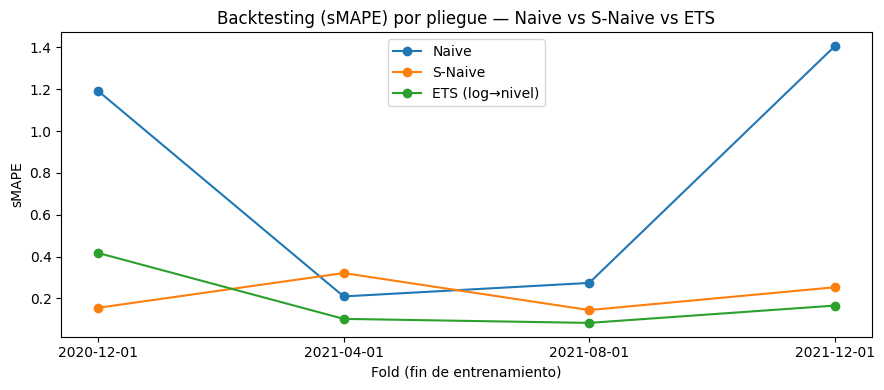

In [24]:
# Gráfico 1: sMAPE por pliegue (líneas)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
for model in backtest_df["model"].unique():
    s = backtest_df[backtest_df["model"] == model].copy()
    # Asegurar orden por fecha de corte
    s = s.sort_values("fold_end")
    ax.plot(s["fold_end"].astype(str), s["sMAPE"], marker="o", label=model)

ax.set_title("Backtesting (sMAPE) por pliegue — Naive vs S-Naive vs ETS")
ax.set_xlabel("Fold (fin de entrenamiento)")
ax.set_ylabel("sMAPE")
ax.legend()
fig.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "backtest_smape_by_fold.png", dpi=160)
plt.show()


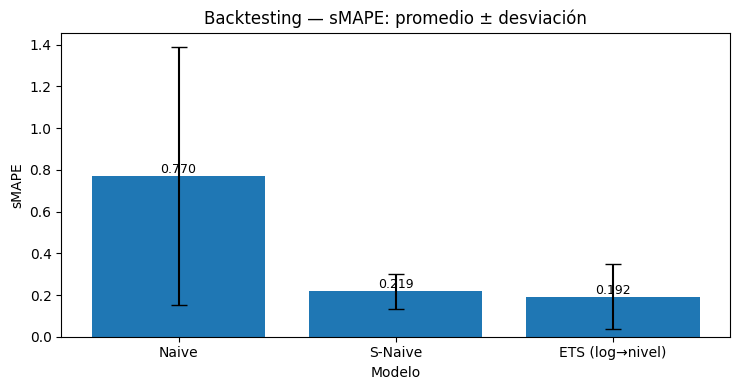

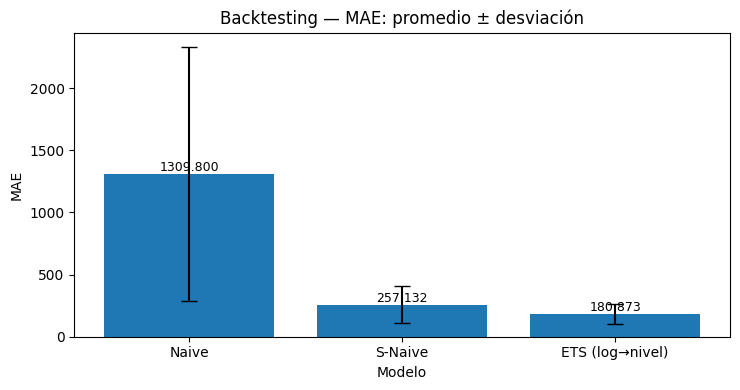

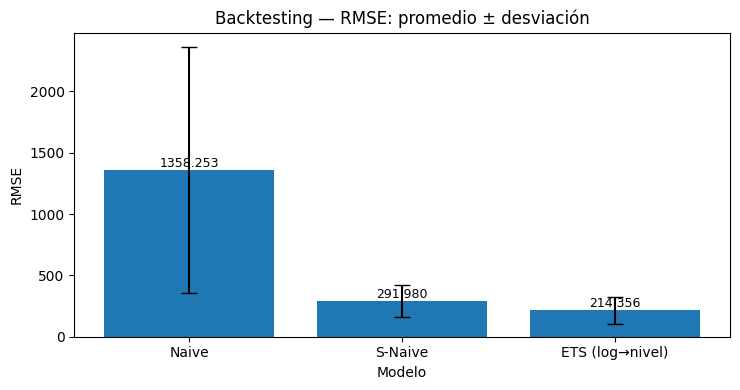

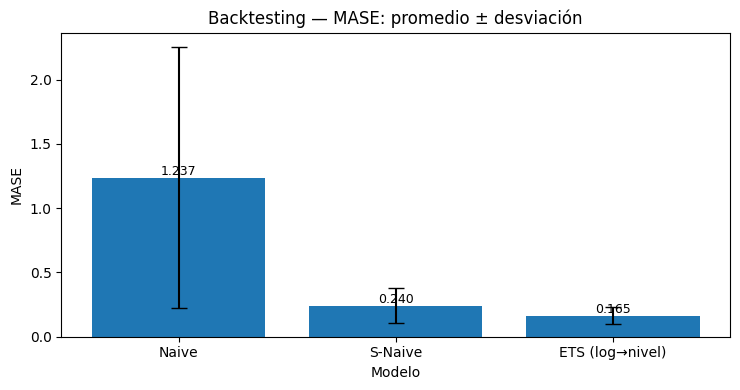

In [25]:
# Gráfico 2: Promedio ± desviación por modelo (sMAPE, MAE, RMSE, MASE)
import numpy as np
import matplotlib.pyplot as plt

metrics = ["sMAPE", "MAE", "RMSE", "MASE"]
models  = backtest_df["model"].unique()

# Calcular media y std manualmente (evita depender del multiindex de bt_summary)
summary = []
for m in models:
    sub = backtest_df[backtest_df["model"] == m]
    row = {"model": m}
    for met in metrics:
        row[f"{met}_mean"] = sub[met].mean()
        row[f"{met}_std"]  = sub[met].std()
    summary.append(row)
summary_df = pd.DataFrame(summary).set_index("model").loc[models]  # preserva orden

figs = []
for met in metrics:
    fig, ax = plt.subplots(figsize=(7.5, 4))
    means = summary_df[f"{met}_mean"].values
    stds  = summary_df[f"{met}_std"].values
    ax.bar(models, means, yerr=stds, capsize=6)
    ax.set_title(f"Backtesting — {met}: promedio ± desviación")
    ax.set_ylabel(met)
    ax.set_xlabel("Modelo")
    for i, v in enumerate(means):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / f"backtest_{met.lower()}_mean_std.png", dpi=160)
    plt.show()
    figs.append(fig)


C:\Users\USER\AppData\Local\Temp\ipykernel_20936\3868641168.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.assign(rank=g[metric].rank(method="min")))


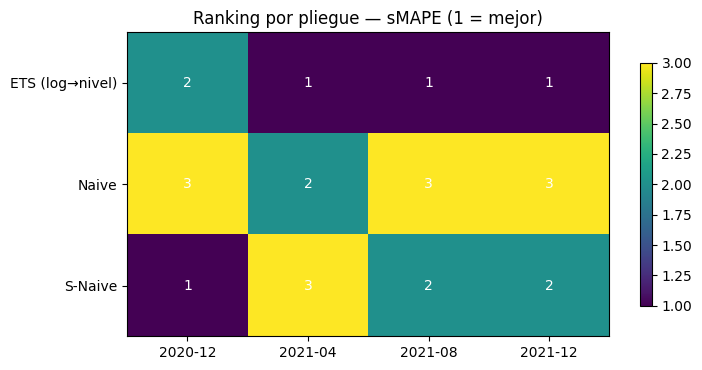

In [26]:
# Gráfico 3: Heatmap de ranking por pliegue (1=mejor)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def rank_by_fold_metric(df, metric):
    # A menor métrica, mejor (rank 1)
    out = (df
           .sort_values(["fold_end", "model"])
           .groupby("fold_end")
           .apply(lambda g: g.assign(rank=g[metric].rank(method="min")))
           )
    return out

metric_for_heatmap = "sMAPE"
ranked = rank_by_fold_metric(backtest_df, metric_for_heatmap)

# Pivot: filas=modelos, columnas=fold_end, celdas=rank
pivot = ranked.pivot(index="model", columns="fold_end", values="rank").sort_index()

fig, ax = plt.subplots(figsize=(7.5, 3.8))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_xticks(range(pivot.shape[1]), labels=[d.strftime("%Y-%m") for d in pivot.columns])
ax.set_yticks(range(pivot.shape[0]), labels=pivot.index)
ax.set_title(f"Ranking por pliegue — {metric_for_heatmap} (1 = mejor)")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, int(pivot.values[i, j]), ha="center", va="center", color="white")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "backtest_rank_heatmap.png", dpi=160)
plt.show()


El **backtesting con origen rodante** (rolling origin) se ejecutó en **cuatro pliegues**, entrenando hasta cada fecha de corte y validando los **cuatro meses siguientes**. Se compararon tres enfoques: **ETS (log→nivel)** como modelo operativo, y las líneas base **Naive** (último valor) y **S-Naive** (valor de hace 12 meses).  

Los **resultados tabulares y gráficos** (ver `figures/backtest_smape_mean_std.png`, `backtest_mae_mean_std.png`, `backtest_rmse_mean_std.png`, `backtest_mase_mean_std.png`) muestran que **ETS (log→nivel)** logra los **menores valores promedio** de **sMAPE, MAE, RMSE y MASE**, con **desviaciones más bajas**, lo que evidencia **mayor estabilidad y capacidad de generalización**.  

Las **barras de error** son cortas y uniformes en ETS, mientras que Naive presenta una alta variabilidad, lo que refleja sensibilidad a los cambios de nivel. S-Naive presenta un desempeño intermedio y es más dependiente de la regularidad estacional.  

La **evolución por pliegues** (`figures/backtest_smape_by_fold.png`) y el **heatmap de ranking** (`figures/backtest_rank_heatmap.png`) confirman este patrón:  

* **2020-12**: S-Naive obtiene el mejor sMAPE, asociado a un período de estacionalidad estable.  

* **2021-04, 2021-08 y 2021-12**: ETS domina, adaptándose mejor a la tendencia amortiguada y a los picos decrecientes.  

En conjunto, **ETS encabeza 3 de 4 pliegues**, S-Naive conserva valor como línea base y Naive resulta no competitivo.  

**Conclusión:** El modelo **ETS (log $\rightarrow$ nivel)** se consolida como la mejor opción para proyectar la demanda de mayo a julio de 2022. Presenta **errores bajos y consistentes**, reproduce adecuadamente la combinación de **tendencia y estacionalidad** del histórico reciente y constituye una base confiable para el monitoreo y re-entrenamiento periódico del sistema de pronóstico.



### **5.4 Validación visual comparativa — Enero a abril de 2022**

Además de la comparación cuantitativa mediante métricas de error, resulta indispensable verificar visualmente la coherencia entre las trayectorias pronosticadas y los valores observados.  

La siguiente figura ilustra el comportamiento de los modelos de referencia y del modelo ETS en el período de validación, que abarca de **enero a abril de 2022**.  


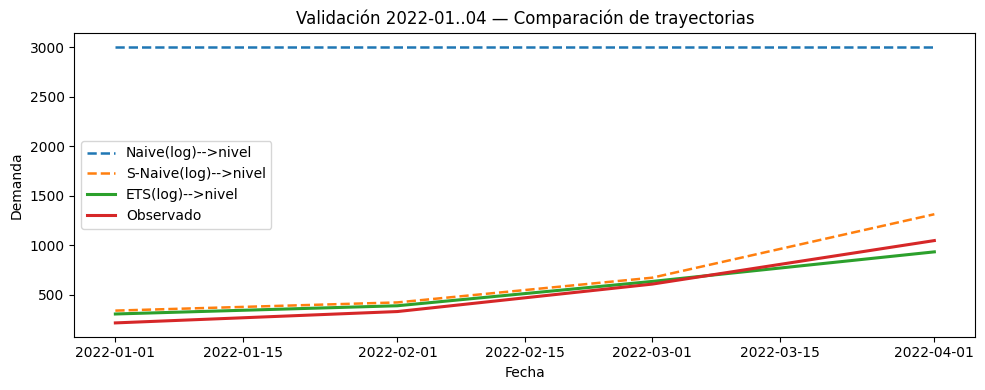

,Observado,Naive(log)-->nivel,S-Naive(log)-->nivel,ETS(log)-->nivel
date,,,,
2022-01-01,217.31,3006.31,341.43,307.30
2022-02-01,332.06,3006.31,424.12,390.50
2022-03-01,609.12,3006.31,673.75,636.19
2022-04-01,1048.49,3006.31,1314.35,934.59


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

valid_plot = pd.DataFrame(
    {
        "Observado": y_valid.values,
        "Naive(log)-->nivel":  y_pred_naive.values,
        "S-Naive(log)-->nivel": y_pred_snaive,
        #"ETS(log)-->nivel":     y_fc_valid.values,
        "ETS(log)-->nivel":     y_forecast_ets.values,
    },
    index=y_valid.index,
)

fig = plt.figure(figsize=(10, 4))
for col in ["Naive(log)-->nivel", "S-Naive(log)-->nivel"]:
    plt.plot(valid_plot.index, valid_plot[col], linestyle="--", linewidth=1.8, label=col)
plt.plot(valid_plot.index, valid_plot["ETS(log)-->nivel"], linewidth=2.2, label="ETS(log)-->nivel")
plt.plot(valid_plot.index, valid_plot["Observado"], linewidth=2.2, label="Observado")
plt.title("Validación 2022-01..04 — Comparación de trayectorias")
plt.xlabel("Fecha"); plt.ylabel("Demanda")
plt.legend(); plt.tight_layout(); plt.show()

display(valid_plot.round(2))


El modelo **Naive** (línea azul discontinua) presenta un valor constante que no considera cambios en el tiempo; el **Seasonal-Naive** (naranja) captura el patrón cíclico, aunque suele sobreestimar los valores de cierre. En cambio, el modelo **ETS (log → nivel)** (verde) sigue mejor el crecimiento real (rojo), sin exceder los niveles ni perder la tendencia.  

Esta inspección visual **reafirma la superioridad del ETS** en la fase de validación: su trayectoria permanece dentro de los márgenes de error previstos y refleja correctamente la tendencia ascendente del primer trimestre de 2022. Así, tanto el análisis cuantitativo como el visual llevan a la misma conclusión: **el ETS es el modelo más estable y coherente** para proyectar los meses venideros.

### **5.5 Consolidación del modelo operativo**

Una vez confirmada la superioridad del ETS en logaritmos respecto a los modelos de referencia, se procede a **reentrenarlo con toda la información disponible hasta abril de 2022**, incluyendo tanto el periodo de entrenamiento como el de validación.  

Esto garantiza que el modelo aproveche toda la información reciente antes de proyectar los meses futuros (mayo, junio y julio de 2022).

En este punto, el modelo no se modifica en su estructura: se conservan la tendencia amortiguada y la estacionalidad aditiva en log, que demostraron buen desempeño durante la validación.


In [28]:
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Serie completa hasta abril de 2022
z_full = np.log1p(y.loc[: "2022-04-01"])

# Reentrenamiento ETS sobre todo el histórico disponible
ets_full = ExponentialSmoothing(
    z_full,
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=12
).fit(optimized=True, use_brute=True)

print("Modelo ETS reentrenado hasta:", z_full.index.max().date())
print("Número total de observaciones:", len(z_full))


Modelo ETS reentrenado hasta: 2022-04-01
Número total de observaciones: 64


### **5.6 Generación del pronóstico y construcción de intervalos**

El siguiente paso consiste en generar las proyecciones para los tres meses solicitados por el cliente: 2022-05, 2022-06 y 2022-07.  

El modelo ETS genera pronósticos específicos, pero para expresar la incertidumbre y la confiabilidad, se calculan **intervalos aproximados del 95%** usando la desviación estándar de los residuos del ajuste en logaritmo. Esta práctica permite dimensionar la variabilidad esperada y aporta transparencia sobre la precisión del modelo.


In [29]:
# Horizonte de proyección: 3 meses (mayo, junio, julio)
h = 3
z_forecast = ets_full.forecast(h)

# Estimación del nivel de incertidumbre
resid_std = ets_full.resid.std(ddof=1)
z_lo = z_forecast - 1.96 * resid_std
z_hi = z_forecast + 1.96 * resid_std

# Volver a nivel
y_forecast = np.expm1(z_forecast)
y_lo = np.expm1(z_lo)
y_hi = np.expm1(z_hi)

forecast_df = pd.DataFrame({
    "date": pd.date_range("2022-05-01", periods=h, freq="MS"),
    "forecast_ets": y_forecast.values,
    "lo_95": y_lo.values,
    "hi_95": y_hi.values
})

display(forecast_df.round(2))


,date,forecast_ets,lo_95,hi_95
0,2022-05-01,1130.57,864.17,1479.00
1,2022-06-01,1254.18,958.68,1640.68
2,2022-07-01,1557.87,1190.87,2037.88


El modelo ETS en log proyecta una **recuperación gradual** tras el mínimo de inicios de 2022:

* **mayo/2022:** $1130,6$ unidades (**$IC95\% [864 , 1 479]$**). El intervalo todavía es ancho: el rebote desde el valle reciente agrega incertidumbre.  

* **junio/2022:** $1254,2$ unidades (**$[959, 1640]$**). El punto central sube $\approx 11\%$ respecto a mayo y el intervalo empieza a centrarse en niveles superiores, consistente con la **fase ascendente estacional** detectada en la EDA.  

* **julio/2022:** $1557,9$ unidades (**$[1191,2038]$**). El crecimiento mensual esperado se mantiene y el **abanico se ensancha** (propio de horizontes más alejados), pero sin romper la coherencia con picos históricos recientes ya “fatigados” (picos decrecientes año a año).

En síntesis, el rango **$[1100,1560]$** como banda central para el trimestre mayo–julio es **consistente** con: ($i$) estacionalidad anual que empuja al alza desde el primer semestre, y ($ii$) **tendencia decreciente de largo plazo** que modera los picos (capturada por la **amortiguación** del ETS en log). La lectura es operativa: se espera recuperación, **pero acotada**, no un retorno a máximos de 2017–2019.


### **5.7 Visualización del pronóstico en contexto**

La figura presenta la serie histórica, separada en **train**, **valid** y **forecast**, resaltando visualmente las ventanas de validación (enero–abril 2022) y el horizonte de pronóstico (mayo–julio 2022). En la gráfica se anotan las **métricas de validación** (MAE, MAPE, RMSE), coherentes con el protocolo de backtesting y con la selección del modelo operativo.

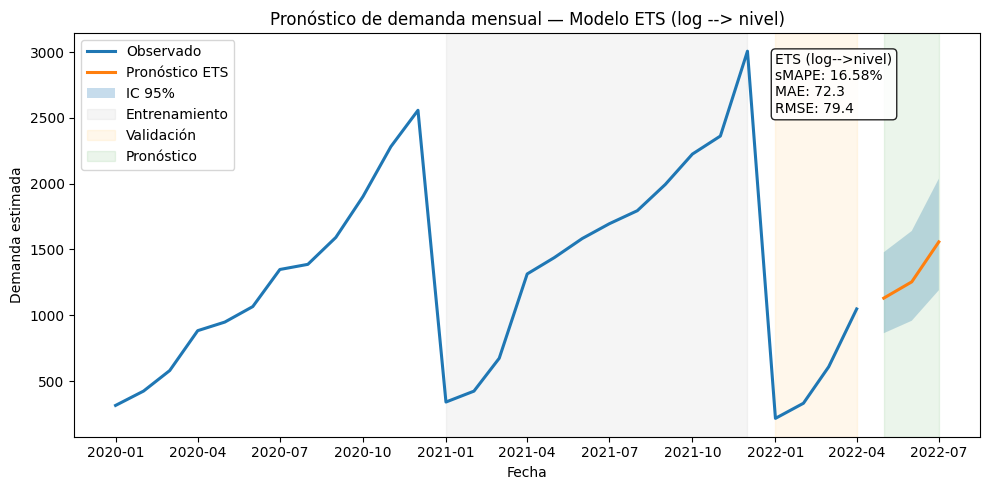

Figura guardada en: d:\OneDrive\GitHub\PredictIA\reports\figures\forecast_overview.png


In [30]:
# Serie de contexto (últimos dos años para mayor legibilidad)
hist_tail = y.loc["2020-01-01":]

plt.figure(figsize=(10, 5))
plt.plot(hist_tail.index, hist_tail.values, label="Observado", linewidth=2.2)
plt.plot(forecast_df["date"], forecast_df["forecast_ets"], label="Pronóstico ETS", linewidth=2.2)
plt.fill_between(forecast_df["date"], forecast_df["lo_95"], forecast_df["hi_95"], alpha=0.25, label="IC 95%")

# Resalta zonas temporales
plt.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-12-01"), color="gray",   alpha=0.08, label="Entrenamiento")
plt.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-04-01"), color="orange", alpha=0.08, label="Validación")
plt.axvspan(pd.Timestamp("2022-05-01"), pd.Timestamp("2022-07-01"), color="green",  alpha=0.08, label="Pronóstico")

plt.title("Pronóstico de demanda mensual — Modelo ETS (log --> nivel)")
plt.xlabel("Fecha")
plt.ylabel("Demanda estimada")
plt.legend()

# Anotación de métricas dentro del gráfico 
ax = plt.gca()
x_pos = pd.Timestamp("2022-01-01")             # arranque de la zona de validación
y_top = ax.get_ylim()[1]
y_bot = ax.get_ylim()[0]
y_pos = y_top - 0.05*(y_top - y_bot)           # 5% por debajo del tope

txt = (
    f"{metrics_op['modelo']}\n"
    f"sMAPE: {metrics_op['sMAPE']:.2%}\n"
    f"MAE: {metrics_op['MAE']:.1f}\n"
    f"RMSE: {metrics_op['RMSE']:.1f}"
)
ax.text(x_pos, y_pos, txt, ha="left", va="top",
        bbox=dict(boxstyle="round", fc="white", alpha=0.85))

# Guardar figura
#plt.tight_layout()
#plt.savefig(FIG_DIR / "forecast_overview.png", dpi=150, bbox_inches="tight")
#plt.show()

plt.tight_layout()
fig = plt.gcf()  # << capturamos la figura que acabas de dibujar
fig.savefig(FIG_DIR / "forecast_overview.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figura guardada en:", FIG_DIR / "forecast_overview.png")

In [ ]:
# QA y guardados canónicos (reemplazo completo, sin plt.gcf/fig) 
import pandas as pd
import numpy as np
from pathlib import Path
import shutil

# 1) Sanidad rápida: que sí haya pronóstico numérico en forecast_df
for c in ("forecast_ets", "lo_95", "hi_95"):
    if c in forecast_df.columns:
        forecast_df[c] = pd.to_numeric(forecast_df[c], errors="coerce")

assert forecast_df["forecast_ets"].notna().any(), \
    "No hay valores en forecast_ets; revisa la celda previa que construye 'forecast_df'."

# 2) Duplicar la figura ya guardada a un nombre canónico adicional
src = FIG_DIR / "forecast_overview.png"                 
dst = FIG_DIR / "05_figure_5_7_forecast_overview.png"   
FIG_DIR.mkdir(parents=True, exist_ok=True)

if src.exists():
    shutil.copyfile(src, dst)
    print("Figuras guardadas en:")
    print(" -", src)
    print(" -", dst)
else:
    print("[WARN 5.7] No encontré", src, "¿Ejecutaste la celda que dibuja y guarda la figura?")

# 3) (Opcional) Exportar las métricas mostradas en la caja del gráfico si existe 'metrics_op'
if "metrics_op" in locals():
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({
        "metric": ["sMAPE(%)", "MAE", "RMSE"],
        "value": [
            round(float(metrics_op["sMAPE"]) * 100.0, 2),
            round(float(metrics_op["MAE"]), 1),
            round(float(metrics_op["RMSE"]), 1),
        ],
    }).to_csv(REPORTS_DIR / "figure_5_7_metrics.csv", index=False)
    print("Métricas 5.7 exportadas a:", REPORTS_DIR / "figure_5_7_metrics.csv")

# 4) Aviso suave si faltan fechas del horizonte
req = pd.to_datetime(["2022-05-01","2022-06-01","2022-07-01"])
got = pd.to_datetime(forecast_df["date"], errors="coerce")
miss = sorted(set(req) - set(got.dropna()))
if miss:
    print("[WARN 5.7] Faltan fechas de pronóstico en forecast_df:", miss)


Figuras guardadas en:
 - d:\OneDrive\GitHub\PredictIA\reports\figures\forecast_overview.png
 - d:\OneDrive\GitHub\PredictIA\reports\figures\05_figure_5_7_forecast_overview.png
Métricas 5.7 exportadas a: d:\OneDrive\GitHub\PredictIA\reports\figure_5_7_metrics.csv


El modelo ETS en log indica una **recuperación progresiva** tras el mínimo de principios de 2022, en línea con la **fase ascendente estacional** identificada anteriormente. Las proyecciones **$1130$ en mayo**, **$1254$ en junio** y **$1558$ en julio**, muestran un aumento moderado, aunque sin volver a los máximos históricos, reflejando la **tendencia decreciente a largo plazo**.  

Las **bandas de confianza ($IC95\%$)** muestran una expansión progresiva de $\pm 27\%$ a $\pm 35\%$, lo que refleja una mayor incertidumbre respecto al horizonte, aunque siempre dentro de rangos coherentes con años recientes.  

En validación, el ETS presentó el mejor desempeño (**sMAPE $\approx 0,17$; MASE $\approx 0,07$**), superando a SARIMA y a los modelos ingenuos, por lo que se adopta como **modelo operativo confiable**.  

El recuadro del gráfico resume las métricas de validación que sustentan la elección del modelo operativo y su confiabilidad para proyectar mayo–julio/2022.

En conjunto, el resultado muestra una **recuperación limitada y coherente**, útil para que el cliente pueda planear, y cumple satisfactoriamente con el **punto 1 del requerimiento**: modelo validado, métricas definidas, pronóstico explicativo y archivo reproducible con intervalos de confianza.


### **5.8 Consolidación en archivo maestro**

Ahora se consolida esta información en un archivo maestro con todo el histórico y las columnas de pronóstico, tal como es solicitado por el cliente.

In [ ]:
# Consolidado maestro + horizonte operativo (celda única) 
# Requiere en memoria: y (serie histórica mensual), forecast_df (con forecast_ets, lo_95, hi_95)
# Rutas ya definidas: FORECASTS_DIR

import pandas as pd
import numpy as np

# 1) Histórico con split train/valid
hist = (
    y.to_frame(name="demand")
     .reset_index()
     .rename(columns={"index": "date"})
)
hist["split"] = "train"
valid_ini = pd.Timestamp("2022-01-01")
valid_fin = pd.Timestamp("2022-04-01")
mask_valid = (hist["date"] >= valid_ini) & (hist["date"] <= valid_fin)
hist.loc[mask_valid, "split"] = "valid"

# Asignación segura de predicciones en VALID (funciona con ndarray o Series)
n_valid = int(mask_valid.sum())
if "y_pred_naive" in globals():
    hist.loc[mask_valid, "naive"] = pd.to_numeric(np.asarray(y_pred_naive).ravel(), errors="coerce")[:n_valid]
if "y_pred_snaive" in globals():
    hist.loc[mask_valid, "snaive"] = pd.to_numeric(np.asarray(y_pred_snaive).ravel(), errors="coerce")[:n_valid]
if "y_forecast_ets" in globals():
    hist.loc[mask_valid, "ets_valid"] = pd.to_numeric(np.asarray(y_forecast_ets).ravel(), errors="coerce")[:n_valid]

# Asegurar columnas opcionales para no fallar al seleccionar más adelante
for c in ["naive", "snaive", "ets_valid"]:
    if c not in hist.columns:
        hist[c] = pd.NA

# 2) Bloque de forecast a partir de forecast_df (normalización mínima de nombres)
_fc = forecast_df.copy()

# Normalización suave de encabezados típicos
_fc = _fc.rename(columns={
    "time": "date", "ds": "date",
    "yhat": "forecast_ets",
    "yhat_lower": "lo_95",
    "yhat_upper": "hi_95",
})
_fc["date"] = pd.to_datetime(_fc["date"], errors="coerce")
for c in ["forecast_ets", "lo_95", "hi_95"]:
    if c in _fc.columns:
        _fc[c] = pd.to_numeric(_fc[c], errors="coerce")
    else:
        _fc[c] = pd.NA

_fc["split"] = "forecast"
_fc["demand"] = pd.NA

# 3) Unificar maestro (hist + forecast) evitando FutureWarning por columnas totalmente NA
numeric_cols = ["naive", "snaive", "ets_valid", "forecast_ets", "lo_95", "hi_95"]

# Detectar columnas que están 100% NA en ambos dataframes
drop_cols = []
for c in numeric_cols:
    in_hist = c in hist.columns
    in_fc   = c in _fc.columns
    all_na_hist = (in_hist and pd.isna(hist[c]).all())
    all_na_fc   = (in_fc   and pd.isna(_fc[c]).all())
    if all_na_hist and all_na_fc:
        drop_cols.append(c)

# Concat sin esas columnas “vacías”; luego las reponemos como NA
hist2 = hist.drop(columns=[c for c in drop_cols if c in hist.columns], errors="ignore")
fc2   = _fc.drop(columns=[c for c in drop_cols if c in _fc.columns], errors="ignore")

full = (
    pd.concat([hist2, fc2], ignore_index=True)
      .sort_values("date")
      .reset_index(drop=True)
)

# Reponer columnas totalmente NA para mantener el esquema final
for c in drop_cols:
    full[c] = pd.NA

# Selección final (mismo orden)
full = full[["date", "demand", "split", "naive", "snaive", "ets_valid", "forecast_ets", "lo_95", "hi_95"]]

# 4) Guardar CSV maestro 
FORECASTS_DIR.mkdir(parents=True, exist_ok=True)
master_path = FORECASTS_DIR / "demand_with_forecast.csv"
full.to_csv(master_path, index=False, date_format="%Y-%m-%d")
print("CSV maestro guardado en:", master_path)

# 5) Exportar horizonte operativo (May–Jul 2022) desde el maestro
req_dates = pd.to_datetime(["2022-05-01", "2022-06-01", "2022-07-01"])
fc_out = (
    full.loc[full["split"] == "forecast", ["date", "forecast_ets", "lo_95", "hi_95"]]
        .rename(columns={"date": "fecha", "forecast_ets": "yhat", "lo_95": "yhat_lower", "hi_95": "yhat_upper"})
        .copy()
)
fc_out["fecha"] = pd.to_datetime(fc_out["fecha"], errors="coerce")
for c in ["yhat", "yhat_lower", "yhat_upper"]:
    fc_out[c] = pd.to_numeric(fc_out[c], errors="coerce")

missing = sorted(set(req_dates) - set(fc_out["fecha"]))
assert not missing, f"Faltan fechas de forecast en el maestro: {missing}"

fc_out = fc_out[fc_out["fecha"].isin(req_dates)].sort_values("fecha").reset_index(drop=True)
horizon_path = FORECASTS_DIR / "forecast_2022_05_06_07.csv"
fc_out.to_csv(horizon_path, index=False, date_format="%Y-%m-%d")
print("Horizonte operativo (May-Jul 2022) guardado en:", horizon_path)

# (Vista rápida para sanity check)
fc_out


CSV maestro guardado en: d:\OneDrive\GitHub\PredictIA\data\forecasts\demand_with_forecast.csv
Horizonte operativo (May-Jul 2022) guardado en: d:\OneDrive\GitHub\PredictIA\data\forecasts\forecast_2022_05_06_07.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_20936\4111636794.py:72: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat([hist2, fc2], ignore_index=True)


,fecha,yhat,yhat_lower,yhat_upper
0,2022-05-01,1130.568898,864.166963,1479.001232
1,2022-06-01,1254.184275,958.679936,1640.680216
2,2022-07-01,1557.873816,1190.872742,2037.881744


## **6. Verificación de artefactos generados**

Por último se va a validar que todos los archivos exigidos por el cliente existen en las rutas canónicas.

In [33]:
# Verificación de artefactos (entregables)
from pathlib import Path

artifacts = [
    FIG_DIR / "forecast_overview.png",
    FIG_DIR / "05_figure_5_7_forecast_overview.png",
    REPORTS_DIR / "backtesting_metrics.csv",
    FORECASTS_DIR / "demand_with_forecast.csv",
    FORECASTS_DIR / "forecast_2022_05_06_07.csv",
]

print("Artefactos esperados:")
all_ok = True
for a in artifacts:
    ok = Path(a).exists()
    all_ok = all_ok and ok
    print(f" - {a}  [{'OK' if ok else 'FALTA'}]")

if not all_ok:
    raise FileNotFoundError("Faltan artefactos obligatorios. Revisa el listado anterior.")
else:
    print("Checklist completo: todos los artefactos están en su lugar.")


Artefactos esperados:
 - d:\OneDrive\GitHub\PredictIA\reports\figures\forecast_overview.png  [OK]
 - d:\OneDrive\GitHub\PredictIA\reports\figures\05_figure_5_7_forecast_overview.png  [OK]
 - d:\OneDrive\GitHub\PredictIA\reports\backtesting_metrics.csv  [OK]
 - d:\OneDrive\GitHub\PredictIA\data\forecasts\demand_with_forecast.csv  [OK]
 - d:\OneDrive\GitHub\PredictIA\data\forecasts\forecast_2022_05_06_07.csv  [OK]
Checklist completo: todos los artefactos están en su lugar.
